# Importing Required Python Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

In [44]:
df = pd.read_csv("StudentsPerformance.csv")

# Display first 5 rows

In [45]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,grp B,master's degree,standard,none,90.0,95.0,93.0
3,MALE,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,male,group C,some college,standard,none,76.0,78.0,75.0


# Display Shape (row,cloumn) for dataset

In [46]:
df.shape

(1000, 8)

# Dataset Structure Inspection Using

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      996 non-null    object 
 5   math score                   997 non-null    float64
 6   reading score                996 non-null    float64
 7   writing score                998 non-null    float64
dtypes: float64(3), object(5)
memory usage: 62.6+ KB


# Statistical Summary of Numerical Data Using

In [48]:
df.describe()

,math score,reading score,writing score
count,997.000000,996.000000,998.000000
mean,66.126379,69.184739,68.070140
std,15.134938,14.616643,15.202382
min,0.000000,17.000000,10.000000
25%,57.000000,59.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.250000,79.000000
max,100.000000,100.000000,100.000000


# Checking Missing Values 

In [49]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        4
math score                     3
reading score                  4
writing score                  2
dtype: int64

# Fill missing values in categorical column using mode 
- Why the mode is used for categorical data

    - Categorical data has no numerical meaning
    - Mean or median cannot be applied
    - Mode represents the most common category
  - Prevents loss of data due to row deletion


In [50]:
df['test preparation course'] = df['test preparation course'].fillna(
    df['test preparation course'].mode()[0]
)

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     3
reading score                  4
writing score                  2
dtype: int64

# Fill missing values in numeric columns using mean
- Why the mean is used for numerical data

   - Numerical data has quantitative meaning
   - Mean represents the central tendency
   - Easy to compute and widely accepted
   - Keeps dataset size unchanged

In [51]:
df['math score'] = df['math score'].fillna(df['math score'].mean())
df['reading score'] = df['reading score'].fillna(df['reading score'].mean())
df['writing score'] = df['writing score'].fillna(df['writing score'].mean())

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Frequency Distribution of a Categorical Variable gender

In [52]:
df['gender'].value_counts()

gender
female    514
male      478
MALE        2
M           2
F           2
F           1
FEMALE      1
Name: count, dtype: int64

# Frequency Distribution of a Categorical Variable race/ethnicity

In [53]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    318
group D    260
group B    188
group E    140
group A     89
grp B        2
grp D        1
D            1
C            1
Name: count, dtype: int64

# Standardizing Categorical Data to Remove Inconsistencies
This code is used to standardize the values in the gender column by converting all text to lowercase and replacing inconsistent or abbreviated entries with a single, consistent category. This ensures uniform representation of categorical values.

In [54]:
df['gender'] = df['gender'].str.lower()
df['gender'] = df['gender'].replace({
    'm': 'male',
    'male': 'male',
    'female': 'female',
    'f': 'female',
     'f ': 'female'
})
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

# Standardizing the race/ethnicity Categorical Variable to remove inconsistencies
This code is used to remove inconsistencies and standardize the values in the race/ethnicity column. Since categorical variables often contain inconsistent naming conventions, this step ensures all categories follow a uniform format before further preprocessing.

In [55]:
df['race/ethnicity'] = df['race/ethnicity'].str.lower()
df['race/ethnicity'] = df['race/ethnicity'].replace({
    'grp b': 'group b',
    'b': 'group b',
    'grp d': 'group d',
    'd': 'group d',
    'c': 'group c'
})
df['race/ethnicity'] = df['race/ethnicity'].str.title()
df['race/ethnicity'].value_counts()


race/ethnicity
Group C    319
Group D    262
Group B    190
Group E    140
Group A     89
Name: count, dtype: int64

# Detecting Outliers in Numerical Data Using the IQR Method
For each numerical score column, the function calculates lower and upper bounds beyond which values are considered outliers and prints these limits.
- Why the IQR method is used
    - Does not assume normal distribution
    - Robust to skewed data
    - Widely accepted in academic and industry practice
    - Easy to interpret and explain

In [56]:
def detect_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound
numeric_cols = ['math score', 'reading score', 'writing score']

for col in numeric_cols:
    lb, ub = detect_outliers_iqr(df[col])
    print(f"{col}: Lower = {lb:.2f}, Upper = {ub:.2f}")


math score: Lower = 27.00, Upper = 107.00
reading score: Lower = 29.00, Upper = 109.00
writing score: Lower = 26.50, Upper = 110.50


# Box plot for checking outliers
A boxplot is used to visualize the distribution of math, reading, and writing scores in a single frame.
It displays the median, quartiles (Q1 and Q3), and spread of each score.
Points outside the whiskers indicate potential outliers.
This plot helps in comparing variability across different subjects.
It also supports IQR-based outlier detection.

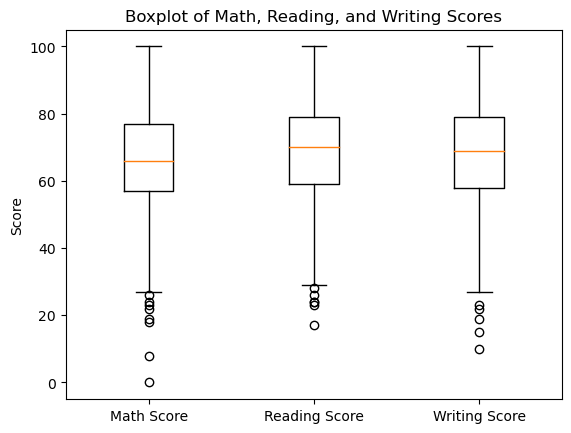

In [57]:
plt.figure()
plt.boxplot(
    [df['math score'], df['reading score'], df['writing score']],
    labels=['Math Score', 'Reading Score', 'Writing Score']
)
plt.ylabel("Score")
plt.title("Boxplot of Math, Reading, and Writing Scores")
plt.show()

# Outliers removal using IQR method  
The IQR (Interquartile Range) method is used to remove outliers from numerical data.
It calculates Q1 and Q3 to determine the spread of the middle 50% of the data.
Values lying below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.
Removing these values helps improve data quality and reduces the impact of extreme observations.

Original rows: 1000
After IQR removal: 986


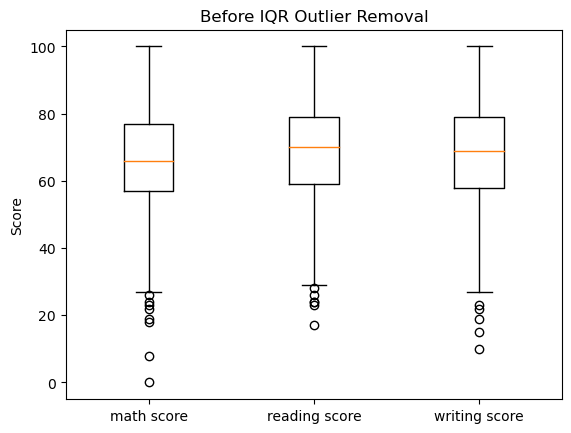

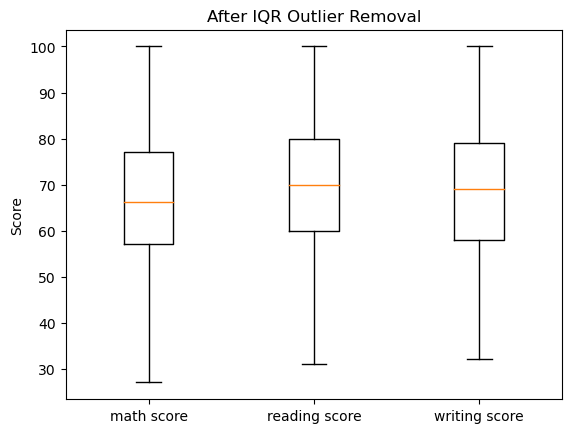

In [58]:
score_cols = ['math score', 'reading score', 'writing score']
df_iqr = df.copy()

for col in score_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]
print("Original rows:", df.shape[0])
print("After IQR removal:", df_iqr.shape[0])
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([df[col] for col in score_cols],
            labels=score_cols)
plt.title("Before IQR Outlier Removal")
plt.ylabel("Score")
plt.show()
plt.figure()
plt.boxplot([df_iqr[col] for col in score_cols],
            labels=score_cols)
plt.title("After IQR Outlier Removal")
plt.ylabel("Score")
plt.show()

# One hot encdoing on categorial data
One-hot encoding is a data preprocessing technique that converts categorical variables into a numerical format that machine learning algorithms can use. It transforms each category into a new binary column, where a value of 1 indicates the presence of that category and 0 indicates its absence

In [59]:
categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

df_encoded = pd.get_dummies(
    df_iqr,                  
    columns=categorical_cols,
    drop_first=True         
)
print("Shape after encoding:", df_encoded.shape)
df_encoded.columns

Shape after encoding: (986, 15)


Index(['math score', 'reading score', 'writing score', 'gender_male',
       'race/ethnicity_Group B', 'race/ethnicity_Group C',
       'race/ethnicity_Group D', 'race/ethnicity_Group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')

# Data transformation for numeric data 
Min–Max scaling is a data transformation technique used to rescale numerical variables to a fixed range, typically 0 to 1.
It preserves the relative order and distribution of the original data while changing the scale.
This method is useful when features have different ranges and need to be normalized.
Min–Max scaling prevents negative values and is suitable for algorithms sensitive to feature scale.

In [60]:
score_cols = ['math score', 'reading score', 'writing score']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

df_minmax = df_encoded.copy()   

df_minmax[score_cols] = scaler.fit_transform(
    df_minmax[score_cols]
)
df_minmax[score_cols].describe()

,math score,reading score,writing score
count,986.000000,986.000000,986.000000
mean,0.544283,0.561436,0.539183
std,0.195679,0.201397,0.212020
min,0.000000,0.000000,0.000000
25%,0.410959,0.420290,0.382353
50%,0.535978,0.565217,0.544118
75%,0.684932,0.710145,0.691176
max,1.000000,1.000000,1.000000


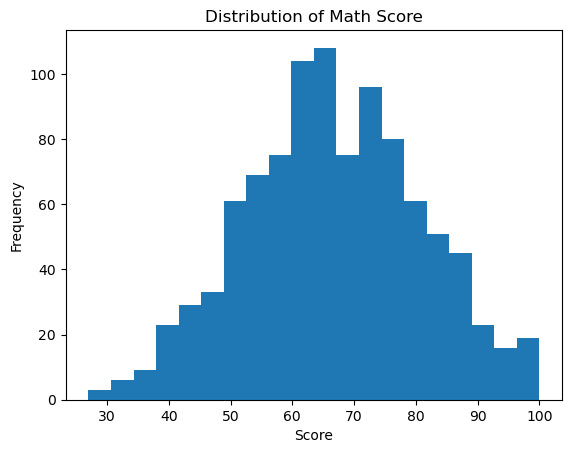

In [65]:
import matplotlib.pyplot as plt

plt.hist(df_iqr['math score'], bins=20)
plt.title("Distribution of Math Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()
